In [10]:
from pathlib import Path
import pandas as pd
import numpy as np 
from  sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import seaborn as sns

In [3]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "cleaned_taxi_data.csv")
df.head(5)

,index_left,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,BoroName
0,4217,id1693416,2,2016-01-12 22:57:13,2016-01-12 23:33:06,1,-73.979324,40.727631,-74.074028,40.640224,N,35.883333,Staten Island
1,16494,id1973056,2,2016-03-22 15:35:52,2016-03-22 16:53:17,1,-73.789642,40.647121,-74.135986,40.624981,N,77.416667,Staten Island
2,17985,id3759847,2,2016-02-04 22:00:26,2016-02-04 22:48:18,2,-73.984749,40.742130,-74.076393,40.599159,N,47.866667,Staten Island
3,19015,id3330882,2,2016-04-02 08:47:43,2016-04-02 08:50:23,1,-74.073433,40.615421,-74.073433,40.615421,N,2.666667,Staten Island
4,19701,id0778469,1,2016-01-01 19:46:50,2016-01-01 20:33:26,1,-73.991974,40.749928,-74.115303,40.574230,N,46.600000,Staten Island


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442002 entries, 0 to 1442001
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   index_left          1442002 non-null  int64  
 1   id                  1442002 non-null  str    
 2   vendor_id           1442002 non-null  int64  
 3   pickup_datetime     1442002 non-null  str    
 4   dropoff_datetime    1442002 non-null  str    
 5   passenger_count     1442002 non-null  int64  
 6   pickup_longitude    1442002 non-null  float64
 7   pickup_latitude     1442002 non-null  float64
 8   dropoff_longitude   1442002 non-null  float64
 9   dropoff_latitude    1442002 non-null  float64
 10  store_and_fwd_flag  1442002 non-null  str    
 11  trip_duration       1442002 non-null  float64
 12  BoroName            1442002 non-null  str    
dtypes: float64(5), int64(3), str(5)
memory usage: 221.1 MB


In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

Remove data leakage

In [6]:

df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)

In [7]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [8]:
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1446659 entries, 0 to 1446658
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   id                 1446659 non-null  str           
 1   pickup_datetime    1446659 non-null  datetime64[us]
 2   passenger_count    1446659 non-null  int64         
 3   pickup_longitude   1446659 non-null  float64       
 4   pickup_latitude    1446659 non-null  float64       
 5   dropoff_longitude  1446659 non-null  float64       
 6   dropoff_latitude   1446659 non-null  float64       
 7   trip_duration      1446659 non-null  float64       
 8   distance           1446659 non-null  float64       
 9   day_of_week        1446659 non-null  int32         
 10  pickup_hour        1446659 non-null  int32         
dtypes: datetime64[us](1), float64(6), int32(2), int64(1), str(1)
memory usage: 110.4 MB


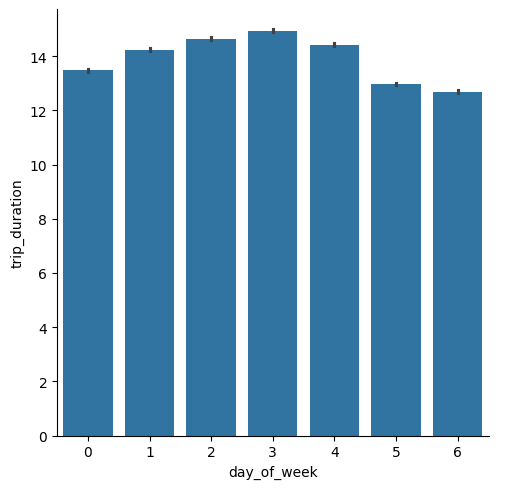

In [9]:
sns.catplot(df,x='day_of_week',y='trip_duration',kind='bar')

In [22]:
X = df.drop(['trip_duration','id','pickup_datetime'],axis=1)
y = df['trip_duration']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [26]:
categorical = X.select_dtypes(include=['str']).columns.to_list()
numerical = X.select_dtypes(include=['float','int']).columns.to_list()
categorical_enc = ColumnTransformer([("category",OneHotEncoder(sparse_output=False),categorical)],remainder='passthrough',verbose_feature_names_out=False)
numerical_enc = ColumnTransformer([("numerical",StandardScaler(),numerical)],remainder='passthrough',verbose_feature_names_out=False)
pipeline = Pipeline(
    [('encoder',categorical_enc),
     ('scaler',numerical_enc),
     ('model',LinearRegression())]
)
pipeline.set_output(transform='pandas')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [28]:

pipeline.fit(X_train,y_train)
prediction = pipeline.predict(X_test)
print(f"Baseline Mean Absolute Error {mean_absolute_error(y_test,prediction):.2f}")
print(f"R2 {r2_score(y_test,prediction):.2f}")

Baseline Mean Absolute Error 4.63
R2 0.32


In [39]:
from sklearn.linear_model import Ridge

In [40]:
categorical = X.select_dtypes(include=['str']).columns.to_list()
numerical = X.select_dtypes(include=['float','int']).columns.to_list()
categorical_enc = ColumnTransformer([("category",OneHotEncoder(sparse_output=False),categorical)],remainder='passthrough',verbose_feature_names_out=False)
numerical_enc = ColumnTransformer([("numerical",StandardScaler(),numerical)],remainder='passthrough',verbose_feature_names_out=False)
pipeline = Pipeline(
    [('encoder',categorical_enc),
     ('scaler',numerical_enc),
     ('model',Ridge())]
)
pipeline.set_output(transform='pandas')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [41]:

pipeline.fit(X_train,y_train)
prediction = pipeline.predict(X_test)
print(f"Baseline Mean Absolute Error {mean_absolute_error(y_test,prediction):.2f}")
print(f"R2 {r2_score(y_test,prediction):.2f}")

Baseline Mean Absolute Error 4.63
R2 0.32
